In [1]:
######## packages
%matplotlib inline
import numpy as np
import pandas as pd
import datetime
import scipy
from sklearn.metrics import log_loss
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
######## packages

In [2]:
####### prediction classes 
class AveragePitchPredictor():

    def __init__(self, state_names):
        self.state_names = state_names
        self.n_states = len(self.state_names)


    def fit(self, at_bats):
        pi = np.zeros([1,self.n_states])
        for at_bat_idx, at_bat in enumerate(at_bats):
            for pitch_idx, pitch_data in at_bat.iterrows():
                pi[0,pitch_data.curr_state_int] += 1
        self.pi = {"NA": {"NA":pi / np.sum(pi)}}
        return
    
    def predict(self, curr_state, split = "NA", pitcher_id = "NA"):
        """
        Predict the distribution of next state
        """
        return self.pi[pitcher_id][split]
    
    def score(self, at_bats, metric = "cross-entropy"):
        """
        Scores the model based on the data from at_bats
        """
        if metric == "cross-entropy":
            ctr = 0
            y_true = []
            y_pred = []
            for at_bat_idx, at_bat in enumerate(at_bats):
                for pitch_idx, pitch_data in at_bat.iterrows():
                    if pitch_idx == at_bat.index[0]:
                        pitcher_id = "NA"
                        pitch_throws = "N"
                        bat_stand = "A"
                        curr_state_dist = self.pi[f"{pitcher_id}"][f"{pitch_throws}{bat_stand}"]
                    next_state_dist = self.predict(curr_state_dist, split=f"{pitch_throws}{bat_stand}", pitcher_id=f"{pitcher_id}")
                    y_pred.append(next_state_dist)
                    last_state = curr_state_dist
                    curr_state_dist = np.zeros([1,self.n_states])
                    curr_state_dist[0,pitch_data.curr_state_int] = 1
                    y_true.append(curr_state_dist)
                    ctr += 1
            y_true = np.concat(y_true, axis=0)
            y_pred = np.concat(y_pred, axis=0)
            metric_val = 100 * np.exp(-log_loss(y_true, y_pred))
        return metric_val
class MarkovPitchPredictor():
    def __init__(self, state_names):
        self.state_names = state_names
        self.n_states = len(self.state_names)

    def fit(self, at_bats):
        self.A = {"NA":{"NA": 1e-0 * np.ones([self.n_states, self.n_states]), 
                        "LL": 1e-0 * np.ones([self.n_states, self.n_states]), 
                        "LR": 1e-0 * np.ones([self.n_states, self.n_states]), 
                        "RL": 1e-0 * np.ones([self.n_states, self.n_states]), 
                        "RR": 1e-0 * np.ones([self.n_states, self.n_states])}}
        self.pi = {"NA":{"NA": 1e-0 * np.zeros([1, self.n_states]), 
                        "LL": 1e-0 * np.zeros([1, self.n_states]), 
                        "LR": 1e-0 * np.zeros([1, self.n_states]), 
                        "RL": 1e-0 * np.zeros([1, self.n_states]), 
                        "RR": 1e-0 * np.zeros([1, self.n_states])}}
        for at_bat_idx, at_bat in enumerate(at_bats):
            for pitch_idx, pitch_data in at_bat.iterrows():
                if pitch_idx == at_bat.index[0]:
                    if f"{pitch_data.pitcher_id}" not in self.A.keys():
                        self.A[f"{pitch_data.pitcher_id}"] = {"NA": 1e-0 * np.ones([self.n_states, self.n_states]), 
                        "LL": 1e-0 * np.ones([self.n_states, self.n_states]), 
                        "LR": 1e-0 * np.ones([self.n_states, self.n_states]), 
                        "RL": 1e-0 * np.ones([self.n_states, self.n_states]), 
                        "RR": 1e-0 * np.ones([self.n_states, self.n_states])}
                        self.pi[f"{pitch_data.pitcher_id}"] = {"NA": 1e-0 * np.zeros([1, self.n_states]), 
                        "LL": 1e-0 * np.zeros([1, self.n_states]), 
                        "LR": 1e-0 * np.zeros([1, self.n_states]), 
                        "RL": 1e-0 * np.zeros([1, self.n_states]), 
                        "RR": 1e-0 * np.zeros([1, self.n_states])}
                    pitcher_id = str(pitch_data.pitcher_id)
                    last_state = pitch_data.curr_state_int
                    bat_stand = pitch_data.stand
                    pitch_throws = pitch_data.p_throws
                    continue
                else:
                    curr_state = pitch_data.curr_state_int
                    self.A[f"{pitcher_id}"][f"{pitch_throws}{bat_stand}"][last_state, curr_state] += 1
                    self.A[f"{pitcher_id}"]["NA"][last_state, curr_state] += 1
                    self.A["NA"][f"{pitch_throws}{bat_stand}"][last_state, curr_state] += 1
                    self.A["NA"]["NA"][last_state, curr_state] += 1
                    last_state = curr_state
        for key0, val0 in self.A.items():
            for key1, val1 in val0.items():
                self.A[key0][key1] = self.A[key0][key1] / np.sum(self.A[key0][key1], axis=1).reshape(-1,1)
                (evals, evecs) = scipy.linalg.eig(self.A[key0][key1], left=True, right=False)
                tmp = list(zip(evals, np.array_split(evecs, self.n_states, axis=1)))
                tmp = sorted(tmp, key = lambda x: np.abs(x[0] - 1))
                pi = tmp[0][1]
                pi = pi / np.sum(pi)
                self.pi[key0][key1] = np.real(pi).reshape(1,-1)
        return
    
    def predict(self, curr_state, pitcher_id="NA", split="NA"):
        next_state_dist = curr_state @ self.A[pitcher_id][split]
        return np.clip(next_state_dist, 0.0, 1.0)
    
    def score(self, at_bats, metric = "cross-entropy", info = [""]):
        """
        Scores the model based on the data from at_bats
        """
        if metric == "cross-entropy":
            ctr = 0
            y_true = []
            y_pred = []
            for at_bat_idx, at_bat in enumerate(at_bats):
                for pitch_idx, pitch_data in at_bat.iterrows():
                    if pitch_idx == at_bat.index[0]:
                        bat_stand = pitch_data.stand
                        pitch_throws = pitch_data.p_throws
                        pitcher_id = str(pitch_data.pitcher_id)
                        if pitcher_id not in self.pi.keys():
                            pitcher_id = "NA"
                        if "split" not in info:
                            bat_stand = "A"
                            pitch_throws = "N"
                        if "pitcher" not in info:
                            pitcher_id = "NA"
                        curr_state_dist = self.pi[f"{pitcher_id}"][f"{pitch_throws}{bat_stand}"]
                    next_state_dist = self.predict(curr_state_dist, split=f"{pitch_throws}{bat_stand}", pitcher_id=f"{pitcher_id}")
                    y_pred.append(next_state_dist)
                    last_state = curr_state_dist
                    curr_state_dist = np.zeros([1,self.n_states])
                    curr_state_dist[0,pitch_data.curr_state_int] = 1
                    y_true.append(curr_state_dist)
                    ctr += 1
            y_true = np.concat(y_true, axis=0)
            y_pred = np.concat(y_pred, axis=0)
            metric_val = 100 * np.exp(-log_loss(y_true, y_pred))
        return metric_val
    
class RFModelPitchPredictor():

    def __init__(self, state_names):
        self.state_names = state_names
        self.n_states = len(self.state_names)
        return
    
    def fit(self, at_bats, features):
        param_grid = {
            'selector__k': [1,2,3,4,5],                 
            'classifier__n_estimators': [10, 25, 100],    
            'classifier__max_depth': [None, 10, 20]
        }
        X, y = [], []
        for at_bat_idx, at_bat in enumerate(at_bats):
            for pitch_idx, pitch_data in at_bat.iterrows():
                X.append(pitch_data[features].values.reshape(1,-1))
                tmp = [list(self.state_names).index(pitch_data["pitch_type"])]
                y.append(tmp)
        X = np.concat(X, axis=0)
        y = np.concat(y, axis=0)
        pipeline = Pipeline([
            ('selector', SelectKBest(score_func=f_classif)),
            ('classifier', RandomForestClassifier())
        ])
        self.rf_mdl = GridSearchCV(
            estimator=pipeline, 
            param_grid=param_grid, 
            cv=5, 
            scoring='accuracy', 
            n_jobs=-1
        )
        self.rf_mdl.fit(X,y)
        
        return
    
    def score(self, at_bats, features, metric="cross-entropy"):
        """
        Scores the model based on the data from at_bats
        """
        if metric == "cross-entropy":
            X, y = [], []
            for at_bat_idx, at_bat in enumerate(at_bats):
                for pitch_idx, pitch_data in at_bat.iterrows():
                    X.append(pitch_data[features].values.reshape(1,-1))
                    tmp = [list(self.state_names).index(pitch_data["pitch_type"])]
                    y.append(tmp)
            X = np.concat(X, axis=0)
            y_true = np.concat(y, axis=0)
            y_pred = self.rf_mdl.predict_proba(X)
            metric_val = 100 * np.exp(-log_loss(y_true, y_pred))

        return metric_val
####### prediction classes

In [3]:
###### functions
def load_pitch_data():
    pitch_data = pd.read_csv("./src/data/Swish_Baseball_project/MLB/pitches.csv")
    print(pitch_data.head())
    return pitch_data

def order_pitches_global(df):
    df.sort_values(["date", "game_pk","at_bat_num","pcount_at_bat"], inplace=True)
    return df

def split_data_by_at_bats(pitch_data):
    pitch_data["date"] = pitch_data["date"].apply(lambda x: datetime.datetime.strptime(x, "%Y-%m-%d"))
    pitch_data = order_pitches_global(pitch_data)
    pitch_data["start_at_bat"] = pitch_data.apply(lambda x: 1 if x.strikes == 0 and x.balls == 0 else 0, axis = 1)
    pitch_data["end_at_bat"] = pitch_data["start_at_bat"].shift(-1)
    pitch_data["end_at_bat"].iat[-1] = 1
    start_ab_ind = pitch_data.index[pitch_data["start_at_bat"].apply(lambda x: bool(x))]
    end_ab_ind = pitch_data.index[pitch_data["end_at_bat"].apply(lambda x: bool(x))]
    at_bats = []
    N = len(start_ab_ind)
    for idx, (s_ind, e_ind) in enumerate(zip(start_ab_ind, end_ab_ind)):
        at_bats.append(pitch_data.loc[s_ind:e_ind].copy())
        if not ((at_bats[-1]["pcount_at_bat"].diff()[1:] == 1).all() and at_bats[-1]["pcount_at_bat"].values[0] == 1):
            at_bats.pop()
    del pitch_data
    return at_bats
###### functions

In [4]:
###### variables
pitch_dict = {"FF":"4-Seam Fastball","SI":"Sinker (2-Seam)","FC":"Cutter",
          "CH":"Changeup","FS":"Split-finger","SC":"Screwball",
          "CU":"Curveball","KC":"Knuckle Curve","CS":"Slow Curve","SL":"Slider",
          "ST":"Sweeper","SV":"Slurve","KN":"Knuckleball","EP":"Eephus","FA":"Other",
          "IN":"Intentional Ball","PO":"Pitchout"}
metric = "cross-entropy"
features = ["balls","strikes","fouls","previous_pitch","previous_previous_pitch"]
###### variables

# Problem Overview

In [5]:
display(Markdown("The aim of this project is to build a model that can predict _with sufficient accuracy_ what the next pitch will be from a particular pitcher. As per usual, " \
"we will start with as simple a model possible and slowly make it more complex in order to improve predictive capabilities."))

The aim of this project is to build a model that can predict _with sufficient accuracy_ what the next pitch will be from a particular pitcher. As per usual, we will start with as simple a model possible and slowly make it more complex in order to improve predictive capabilities.

In [6]:
# import data
pitch_data = load_pitch_data()

C:\Users\sambe\AppData\Local\Temp\ipykernel_7272\792817960.py:3: DtypeWarning: Columns (0: event3, 1: event4) have mixed types. Specify dtype option on import or set low_memory=False.
  pitch_data = pd.read_csv("./src/data/Swish_Baseball_project/MLB/pitches.csv")


        uid  game_pk  year        date  team_id_b  team_id_p  inning  top  \
0  14143226   286874  2011  2011-03-31        108        118       1    1   
1  14143227   286874  2011  2011-03-31        108        118       1    1   
2  14143228   286874  2011  2011-03-31        108        118       1    1   
3  14143229   286874  2011  2011-03-31        108        118       1    1   
4  14143230   286874  2011  2011-03-31        108        118       1    1   

   at_bat_num  pcount_at_bat  ...  runner7_start  runner7_end  runner7_event  \
0           1              1  ...            NaN          NaN            NaN   
1           1              2  ...            NaN          NaN            NaN   
2           1              3  ...            NaN          NaN            NaN   
3           1              4  ...            NaN          NaN            NaN   
4           2              1  ...            NaN          NaN            NaN   

   runner7_score  runner7_rbi  runner7_earned           

In [7]:
pitch_data.shape

(718961, 125)

## Inspect Data

In [8]:
# get percent nan of the raw data
perc_nan = pitch_data.isna().sum(axis=0)/pitch_data.shape[0]

In [9]:
display(Markdown("First of all, we need to clean of the dataset a bit since there are NaNs in the raw data. Since we are predicting the _pitch type_, I am going to drop any rows that " \
f"do not have a value for _pitch type_. Fortunately, _pitch type_ only has {100 * perc_nan["pitch_type"]:0.2f}% NaN values. Most of the other missing data are completely missing or " \
"the column is only missing a few elements. So, we will remove all columns with a percentage of NaNs greater than 50% and drop the rows that contain NaN values."))

First of all, we need to clean of the dataset a bit since there are NaNs in the raw data. Since we are predicting the _pitch type_, I am going to drop any rows that do not have a value for _pitch type_. Fortunately, _pitch type_ only has 0.32% NaN values. Most of the other missing data are completely missing or the column is only missing a few elements. So, we will remove all columns with a percentage of NaNs greater than 50% and drop the rows that contain NaN values.

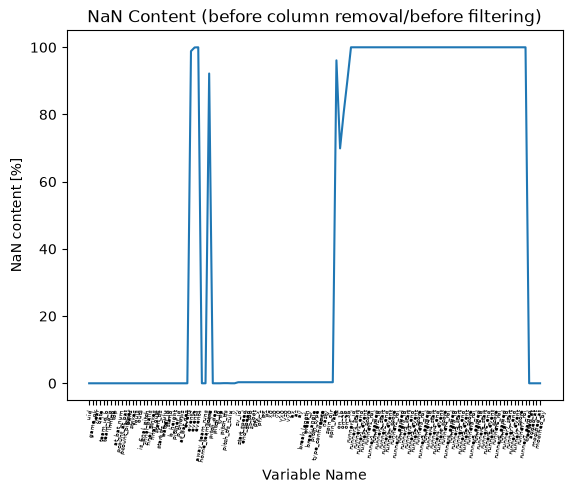

In [10]:
fig = plt.figure()
plt.plot(100 * perc_nan)
plt.ylabel("NaN content [%]")
plt.xlabel("Variable Name")
plt.xticks(rotation=80, fontsize=4)
plt.title("NaN Content (before column removal/before filtering)")
plt.show()

Text(0.5, 1.0, 'NaN Content (after column removal/before filtering)')

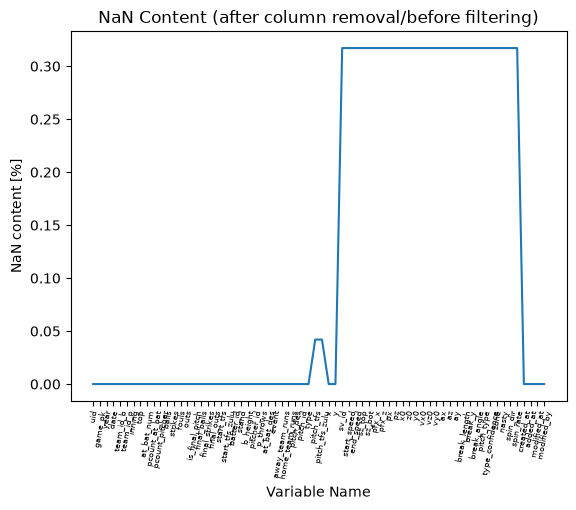

In [11]:
# remove columns with too much data missing
pitch_data = pitch_data[[x for x in pitch_data.columns if perc_nan[x] < 0.5]]
perc_nan = pitch_data.isna().sum(axis=0)/pitch_data.shape[0]
cols_with_nan = [x for x in pitch_data.columns if perc_nan[x] > 0.0]
perc_nan = pitch_data.isna().sum(axis=0)/pitch_data.shape[0]
fig = plt.figure()
plt.plot(100 * perc_nan)
plt.ylabel("NaN content [%]")
plt.xlabel("Variable Name")
plt.xticks(rotation=80, fontsize=6)
plt.title("NaN Content (after column removal/before filtering)")

In [12]:
display(Markdown(f"Since the remaining features have a maximum of {100 * np.max(perc_nan):0.2f}% NaN remaining, I am going to just drop those rows of data"))

Since the remaining features have a maximum of 0.32% NaN remaining, I am going to just drop those rows of data

Text(0.5, 1.0, 'NaN Content (after column removal/after filtering)')

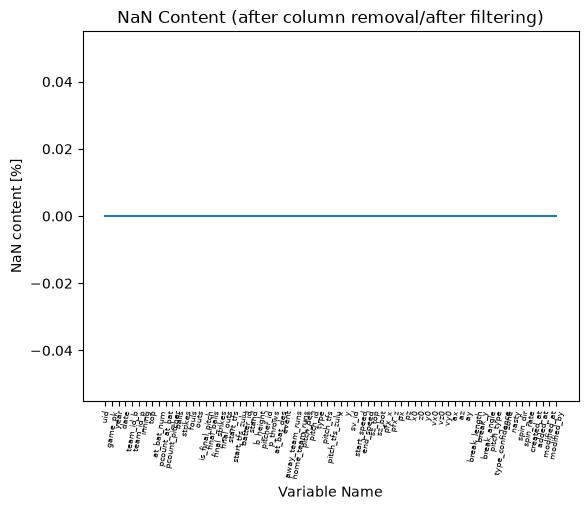

In [13]:
pitch_data.dropna(how="any",axis=0,inplace=True)
perc_nan = pitch_data.isna().sum(axis=0)/pitch_data.shape[0]
fig = plt.figure()
plt.plot(100 * perc_nan)
plt.ylabel("NaN content [%]")
plt.xlabel("Variable Name")
plt.xticks(rotation=80, fontsize=6)
plt.title("NaN Content (after column removal/after filtering)")

In [14]:
display(Markdown("For simplicity, I am also going to remove the pitches that do not occur often like (PO, AB, EP, etc.)."))

For simplicity, I am also going to remove the pitches that do not occur often like (PO, AB, EP, etc.).

In [15]:
pitch_data["states"] = pitch_data["pitch_type"]
pitch_data = pitch_data[pitch_data["states"].apply(lambda x: False if x in ["AB", "EP", "FA", "FO", "PO", "SC", "UN", "IN"] else True)]
poss_states, counts = np.unique(pitch_data["states"], return_counts=True)
percents = 100 * counts / np.sum(counts)

Text(0.5, 1.0, 'Pitch Type Histogram')

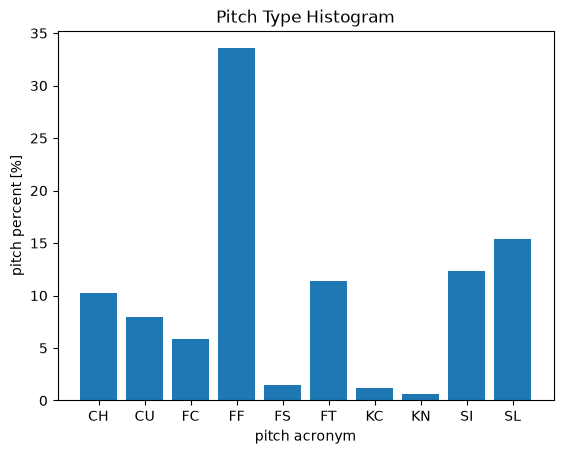

In [16]:
pitch_hist = plt.figure()
plt.bar(poss_states, percents)
plt.ylabel("pitch percent [%]")
plt.xlabel("pitch acronym")
plt.title("Pitch Type Histogram")

In [17]:
display(Markdown("Now, I need to convert each pitch into an integer state which will be used for prediction in both the Markov and Random Forest models."))

Now, I need to convert each pitch into an integer state which will be used for prediction in both the Markov and Random Forest models.

In [18]:
pitch_data["curr_state_int"] = pitch_data["states"].apply(lambda x: list(poss_states).index(x))

In [19]:
display(Markdown("Now, I need to order the data such that this methodology makes sense. I need to break up this data by game and by at-bat. Each new at-bat will be the start of a new Markov Chain. Also, " \
"I need to ensure that each pitch sequence is proper (pitch 1 -> pitch 2 -> pitch 3 etc.) and not (pitch 1 -> pitch 3)."))

Now, I need to order the data such that this methodology makes sense. I need to break up this data by game and by at-bat. Each new at-bat will be the start of a new Markov Chain. Also, I need to ensure that each pitch sequence is proper (pitch 1 -> pitch 2 -> pitch 3 etc.) and not (pitch 1 -> pitch 3).

In [20]:
## feature engineering
pitch_data["previous_pitch"] = pitch_data["pitch_type"].shift(1,fill_value="FF").apply(lambda x: list(poss_states).index(x))
pitch_data["previous_previous_pitch"] = pitch_data["pitch_type"].shift(2,fill_value="FF").apply(lambda x: list(poss_states).index(x))
pitch_data.dropna(how="any",axis=0,inplace=True)


In [21]:
pitch_data.shape

(710957, 72)

In [22]:
# split up data by at-bat
at_bats = split_data_by_at_bats(pitch_data)
# shuffle at-bats
np.random.shuffle(at_bats)

C:\Users\sambe\AppData\Local\Temp\ipykernel_7272\792817960.py:16: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  pitch_data["end_at_bat"].iat[-1] = 1


# Evaluating Models

In [23]:
display(Markdown("It is very important that we utilize a pertinent metric for this problem. This problem can be boiled down to a multi-class classification problem in which the class is the " \
"type of pitch thrown in that scenario. For each model and before each pitch, we can assign a probability of observing a particular class. We can assess each prediction by comparing it to the " \
"true distribution, $\\vec{q}_k$. For example, let's say that a model predicts the following distribution for the $k^{th}$ pitch while the true $k^{th}$ pitch was actually a CH."))

It is very important that we utilize a pertinent metric for this problem. This problem can be boiled down to a multi-class classification problem in which the class is the type of pitch thrown in that scenario. For each model and before each pitch, we can assign a probability of observing a particular class. We can assess each prediction by comparing it to the true distribution, $\vec{q}_k$. For example, let's say that a model predicts the following distribution for the $k^{th}$ pitch while the true $k^{th}$ pitch was actually a CH.

\begin{align}
\vec{p}_k = \left[ \begin{matrix} p_{k,CH} && p_{k,CU} && \dots && p_{k,SL}  \end{matrix} \right]\\
\vec{q}_k = \left[ \begin{matrix} 1.0 && 0.0 && \dots && 0.0  \end{matrix} \right]
\end{align}

In [24]:
display(Markdown("Then, we can compare the prediction and the true outcome with the cross-entropy metric [https://en.wikipedia.org/wiki/Cross-entropy]."))

Then, we can compare the prediction and the true outcome with the cross-entropy metric [https://en.wikipedia.org/wiki/Cross-entropy].

# Baseline Model

In [25]:
display(Markdown("As a baseline, one simplistic method for predicting what the next pitch will be is to predict the average distribution of pitches. This model will " \
"do exactly that. For each pitch, it will assign the average probability of throwing a fastball etc. in all scenarios. To 'train' this model, we will take the trainining " \
"data and calculate the average probability each particular pitch was thrown."))

As a baseline, one simplistic method for predicting what the next pitch will be is to predict the average distribution of pitches. This model will do exactly that. For each pitch, it will assign the average probability of throwing a fastball etc. in all scenarios. To 'train' this model, we will take the trainining data and calculate the average probability each particular pitch was thrown.

# Markov Models

In [26]:
display(Markdown("For this model, we will use a discrete-time Markov Chain to model the process of selecting the next pitch. The intuition behind this Markov Chain is that the next " \
"selected pitch only depends on the last thrown pitch. This should capture the _setup_ pitches in which a pitcher will setup a curveball by throwing a fastball first, for example."))

For this model, we will use a discrete-time Markov Chain to model the process of selecting the next pitch. The intuition behind this Markov Chain is that the next selected pitch only depends on the last thrown pitch. This should capture the _setup_ pitches in which a pitcher will setup a curveball by throwing a fastball first, for example.

\begin{align}
x_k \in S = \text{all possible pitches from pitcher} = \set{FF, SI, FC, \dots}\newline x_{k+1} = A x_{k}
\end{align}

In [27]:
display(Markdown("$A$ is the state transition matrix where $a_{i,j}$ is the probability of transitioning to state $j$ given one is in state $i$ (A is a right or row stochastic matrix)."))

$A$ is the state transition matrix where $a_{i,j}$ is the probability of transitioning to state $j$ given one is in state $i$ (A is a right or row stochastic matrix).

\begin{align}
a_{i,j} = P(x_i | x_j) \forall x_i, x_j \in S
\end{align}

In [28]:
display(Markdown("The Markov Chain also must have an initial distribution, $\\vec{\\pi}_0$, on the probability of starting the Markov chain in each state. This initial distribution will " \
"be identified from the below formulation following [Modeling and Analysis of Stochastic Systems, Kulkarni]."))

The Markov Chain also must have an initial distribution, $\vec{\pi}_0$, on the probability of starting the Markov chain in each state. This initial distribution will be identified from the below formulation following [Modeling and Analysis of Stochastic Systems, Kulkarni].

\begin{align}
\vec{{\pi}}_0 = \vec{{\pi}}_0 A
\end{align}

In [29]:
display(Markdown("This model is termed the _simplest_ model because we will use all available data to create a global, or average, pitcher. This ignores effects from splits (LHP vs LHH, etc.), " \
"counts (0-0, 3-2, etc.), or other factors. We compare adding more information into the model by including split information into the global model, and then pitcher specific information, and " \
"finally pitcher specific split information."))

This model is termed the _simplest_ model because we will use all available data to create a global, or average, pitcher. This ignores effects from splits (LHP vs LHH, etc.), counts (0-0, 3-2, etc.), or other factors. We compare adding more information into the model by including split information into the global model, and then pitcher specific information, and finally pitcher specific split information.

# Random Forest Model

In [30]:
display(Markdown("Additionally, we utilize a random forest model that is fed the following features: balls, strikes, fouls, last pitch, 2nd to last pitch. The model performs a grid search to identify " \
"the salient input features and the set of hyperparameters in the Random Forest model like the number of trees and the max depth of each tree."))

Additionally, we utilize a random forest model that is fed the following features: balls, strikes, fouls, last pitch, 2nd to last pitch. The model performs a grid search to identify the salient input features and the set of hyperparameters in the Random Forest model like the number of trees and the max depth of each tree.

In [31]:
# average pitch model
avg_glob_mdl = AveragePitchPredictor(poss_states)
avg_glob_mdl.fit(at_bats[:int(len(at_bats)/2)])
avg_glob_mdl_metric = avg_glob_mdl.score(at_bats[int(len(at_bats)/2):], metric = metric)
# markov global pitch model
markov_glob_mdl = MarkovPitchPredictor(poss_states)
markov_glob_mdl.fit(at_bats[:int(len(at_bats)/2)])
markov_glob_mdl_metric = markov_glob_mdl.score(at_bats[int(len(at_bats)/2):], metric = metric, info = [""])
markov_glob_split_mdl_metric = markov_glob_mdl.score(at_bats[int(len(at_bats)/2):], metric = metric, info = ["split"])
markov_pitcher_mdl_metric = markov_glob_mdl.score(at_bats[int(len(at_bats)/2):], metric = metric, info = ["pitcher"])
markov_pitcher_split_mdl_metric = markov_glob_mdl.score(at_bats[int(len(at_bats)/2):], metric = metric, info = ["pitcher","split"])
# random forest pitch model
rf_mdl = RFModelPitchPredictor(poss_states)
rf_mdl.fit(at_bats[:int(len(at_bats)/2)], features)
rf_mdl_metric = rf_mdl.score(at_bats[int(len(at_bats)/2):], features)
results = pd.DataFrame([avg_glob_mdl_metric, markov_glob_mdl_metric, markov_glob_split_mdl_metric, markov_pitcher_mdl_metric, markov_pitcher_split_mdl_metric, rf_mdl_metric], index = ["Simplest Baseline Model","Global Markov Model","Global Split Markov Model", "Pitcher Markov Model", "Pitcher Split Markov Model", "Global Random Forest Model"], columns = ["exp(-cross-entropy) [%]"])



In [32]:
results

,exp(-cross-entropy) [%]
Simplest Baseline Model,14.884276
Global Markov Model,17.818707
Global Split Markov Model,18.323021
Pitcher Markov Model,26.622261
Pitcher Split Markov Model,26.003575
Global Random Forest Model,20.307606


In [33]:
display(Markdown("The metric ($e^{\\text{-cross-entropy}}$) can be seen as the average probability of predicting the correct pitch in an at-bat. The results show a large improvement from the baseline model. " \
"As with almost all models, the more complex the model is, the more data-hungry the model becomes. This can be seen in the final Markov Model in which it is likely that there was not enough data for each " \
"pitcher to have a proper representation of how they each pitch to right- and left-handed hitters. This can be mitigated using a conjugate prior for each pitcher. The conjugate prior would follow the heirarchy: " \
"Global Pitcher Model -> Pitcher Model -> Pitcher Split Model. The conjugate prior essentially assumes that (without any data) the distribution of pitches thrown by a new pitch will be similar to the global model, etc. " \
"I plan to come back and properly create these conjugate priors for better modeling of the pitch predictions."))

The metric ($e^{\text{-cross-entropy}}$) can be seen as the average probability of predicting the correct pitch in an at-bat. The results show a large improvement from the baseline model. As with almost all models, the more complex the model is, the more data-hungry the model becomes. This can be seen in the final Markov Model in which it is likely that there was not enough data for each pitcher to have a proper representation of how they each pitch to right- and left-handed hitters. This can be mitigated using a conjugate prior for each pitcher. The conjugate prior would follow the heirarchy: Global Pitcher Model -> Pitcher Model -> Pitcher Split Model. The conjugate prior essentially assumes that (without any data) the distribution of pitches thrown by a new pitch will be similar to the global model, etc. I plan to come back and properly create these conjugate priors for better modeling of the pitch predictions.